In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error



In [62]:
df=pd.read_csv("/content/sample_data/insurance.csv")
print(df)

      age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]


In [63]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [65]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [66]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [67]:
df.shape

(1338, 7)

In [68]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


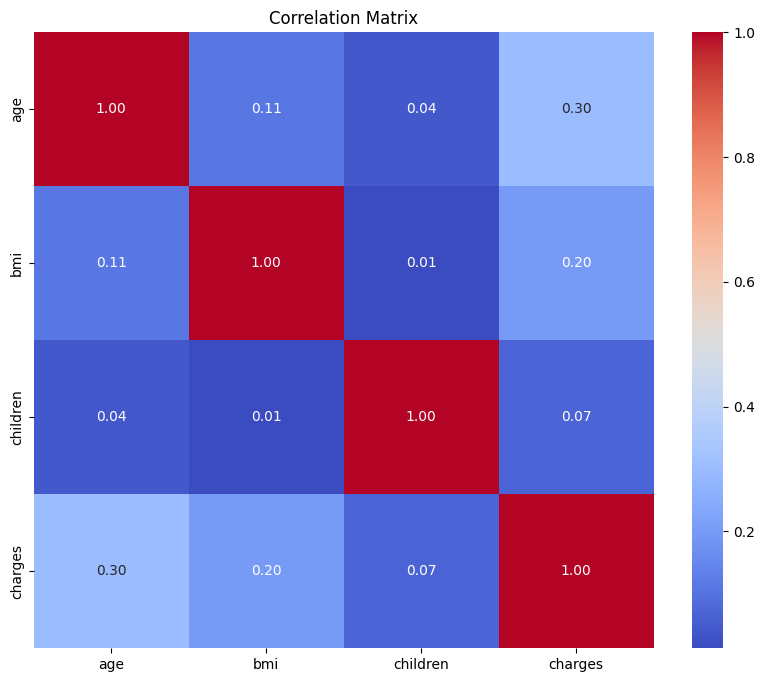

In [69]:
#heatmap to check correlation
plt.figure(figsize=(10, 8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [70]:
#Seperation
X=df[['age']]
y=df['charges']

In [71]:
#split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [72]:
#Train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [73]:
#make predictions
y_pred = model.predict(X_test)
print(y_pred)

[14703.77387469 12538.40483659 19275.10851067 14944.37043448
  8448.26332018 12057.21171701  8448.26332018 19275.10851067
 10613.63235828 15666.16011384 11094.82547785 13741.38763553
 10854.22891807 14944.37043448 18312.72227152 15184.96699426
 15666.16011384 15184.96699426 14944.37043448 14222.58075511
  9891.84267891 14222.58075511  8448.26332018  9170.05299954
 15906.75667363 16869.14291279 18312.72227152 10373.03579849
 15184.96699426  8207.66676039 13500.79107574 17590.93259215
  8929.45643976 11094.82547785 10132.4392387  14703.77387469
  8929.45643976 14222.58075511 16387.94979321 12538.40483659
  8448.26332018  9170.05299954 17350.33603236 18072.12571173
 11816.61515722 18072.12571173  8929.45643976  9891.84267891
 14222.58075511 11335.42203764 19034.51195088  8207.66676039
 13500.79107574  8207.66676039 17350.33603236 15906.75667363
 11094.82547785 11335.42203764 17831.52915194 16628.546353
 19034.51195088 11094.82547785 18553.31883131 13981.98419532
 16387.94979321 10613.6323

In [74]:
#Actual vs predicted
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result)

           Actual     Predicted
764    9095.06825  14703.773875
887    5272.17580  12538.404837
890   29330.98315  19275.108511
1293   9301.89355  14944.370434
259   33750.29180   8448.263320
...           ...           ...
109   47055.53210  19034.511951
575   12222.89830  17831.529152
535    6067.12675  13019.597956
543   63770.42801  16869.142913
846    9872.70100  16147.353233

[268 rows x 2 columns]


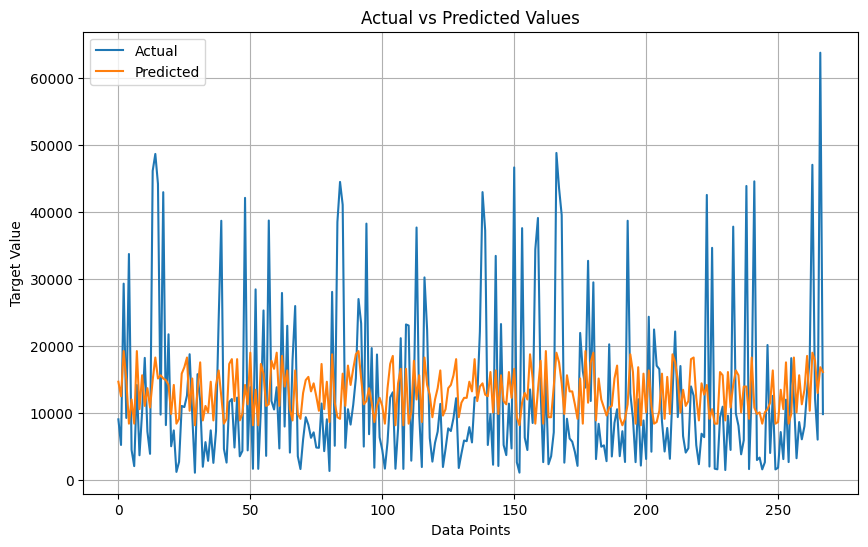

In [75]:
#line graph to visaualize predict with Actual
plt.figure(figsize=(10,6))

sns.lineplot(x=range(len(y_test)),
             y=y_test.values,
             label='Actual')

sns.lineplot(x=range(len(y_pred)),
             y=y_pred,
             label='Predicted')

plt.title('Actual vs Predicted Values')
plt.xlabel('Data Points')
plt.ylabel('Target Value')
plt.grid(True)

plt.show()

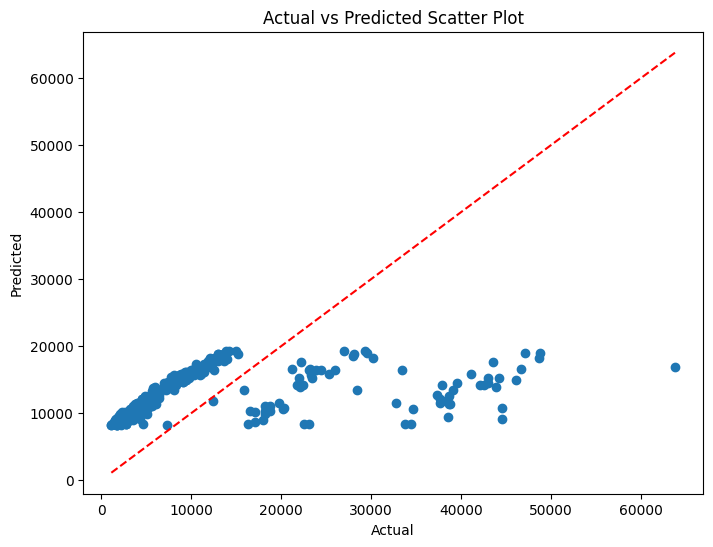

In [76]:
#Scatter Plot
#if points lie close to the diagnol line/Regression line , your model is performing well.
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Scatter Plot')
plt.show()

In [77]:
#it tell how well the model explains the variance in the data
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: 0.12408973539501944


In [78]:
# Mean Absolute Error (MAE)
# Average absolute difference between actual and predicted values
# Lower value = Better model
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 9173.258196746589


In [82]:
# Mean Squared Error (MSE)
# Average of squared differences between actual and predicted values
# Lower value = Better model
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 135983957.4805469


In [79]:
accuracy = r2_score(y_test, y_pred) * 100
print("Accuracy:", accuracy, "%")

Accuracy: 12.408973539501943 %


In [89]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
encoder = LabelEncoder()

# Convert categorical columns into numbers
df['sex'] = encoder.fit_transform(df['sex'])
df['smoker'] = encoder.fit_transform(df['smoker'])
df['region'] = encoder.fit_transform(df['region'])

print(df.head())

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [91]:
X = df.drop('charges', axis=1)
y = df['charges']

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

print(y_pred)

accuracy = r2_score(y_test, y_pred)

print("R² Score:", accuracy)
print("Accuracy (%):", accuracy * 100)

[ 8924.40724442  7116.29501758 36909.01352144  9507.87469118
 27013.3500079  10790.77956153   226.29844571 16942.71599941
  1056.63079407 11267.91997309 28048.59793155  9424.36324087
  5326.32232088 38460.06017922 40303.40597026 37147.01010262
 15287.91876684 35965.05485917  9179.1753067  31510.8319849
  3797.79068365 10070.82803304  2312.57551348  7074.41348194
 11352.37224357 12907.77079523 14448.84678727  6205.65997921
  9917.00839638  2239.50032819  9060.55469043 13120.56214535
  4617.70702822  3467.91218926  4402.74821855 12967.91608907
  1927.44498944  8757.9180081  33324.35180597 32638.47697026
  3852.41756615  4370.39670883 14080.76023234 11478.63402576
  8829.26135924 12046.15119133  5322.80515731  3100.71182484
 35546.60547574  9201.61196817 15894.23763341  2406.04003607
 12397.52052544  1433.90617387 13448.14094304 12519.54174599
  4295.28664609 32202.67982224 13263.171278   12842.10998145
 14111.93665793 10551.59361363 16298.16745307  7818.15570419
 11787.5726767   4113.268

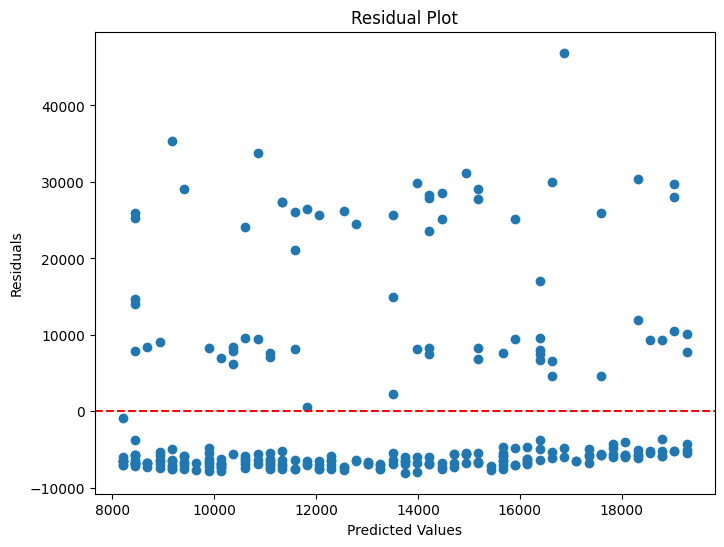

In [80]:
# Residuals represent the difference between actual and predicted values
# They help us understand the prediction error of the model
#Random scatter around 0 → Good model
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

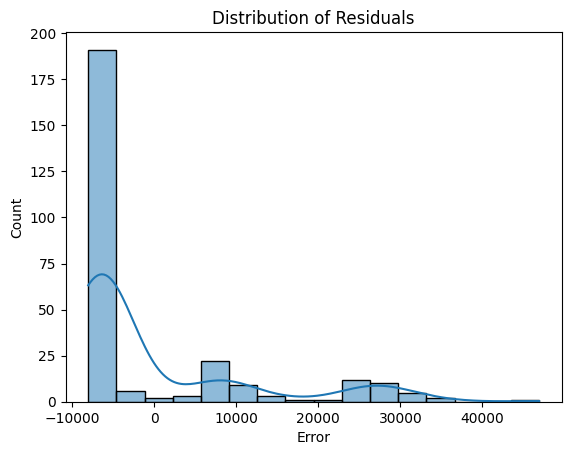

In [81]:
#Bell Shaped-> Good Model
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals')
plt.xlabel('Error')
plt.show()